In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

# import rdkit
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools

import warnings
warnings.filterwarnings("ignore")

import sys
# sys.executable

# Data

In [5]:
import os

from rdkit import Chem
from IPython.display import HTML
from rdkit.Chem import PandasTools
import pandas as pd

def displaydf(df):
    return HTML(df.to_html(notebook=True))

ddir = 'data/'
df = pd.read_csv(os.path.join(ddir,'partial_data.csv'))
df.columns = ['smiles']
display(df)

,smiles
0,c1c(N2C(=O)N3CC(N(CC)Cc4cccc(-c5ccc(C#N)cc5)c4...
1,c1(S(=O)(=O)N(CC)CC)c(C)ccc(C(=O)Nc2ccc(Cl)cn2)c1
2,c1c2oc(-c3cc(O)c(O)c(O)c3)c(OC3C(O)C(O)C(O)C(C...
3,C(c1nc(-c2cccc(NC(=O)c3ccc(C)s3)c2)oc1C)NC(=O)...
4,N(c1ccccc1)C(=O)c1cn(-c2ccccc2)nc1-c1ccc(Cl)cc1
...,...
995,CN(CC(=O)Nc1ccc(Cl)c(c1)C(F)(F)F)C(=O)CC1Sc2cc...
996,CCOc1nc2ccc(OCCC3CCN(CC3)c3ccc(C)nn3)cc2s1
997,CN(C1CS(=O)(=O)CC1)C(COc1ccccc1)=O
998,CCCC(=O)Nc1n[nH]c2cc(Cl)c(cc12)-c1ccc(CC)cc1


,smiles,molecule
0,c1c(N2C(=O)N3CC(N(CC)Cc4cccc(-c5ccc(C#N)cc5)c4...,
1,c1(S(=O)(=O)N(CC)CC)c(C)ccc(C(=O)Nc2ccc(Cl)cn2)c1,

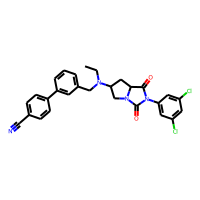
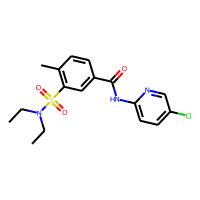

In [40]:
PandasTools.AddMoleculeColumnToFrame(df,'smiles','molecule',includeFingerprints=False)
displaydf(df.head(2))

# Graph representation

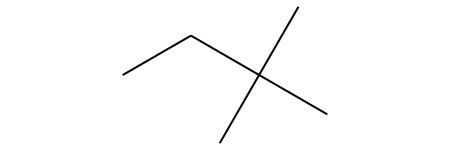

In [75]:
smiles = df.smiles[6]
smiles = 'CCC(C)(C)C'

# mol = Chem.MolFromSmiles(smiles.strip())
# can_smi = Chem.MolToSmiles(mol)
# graph = mol_to_graph(mol)

mol = Chem.MolFromSmiles(smiles)
display(mol)

am = Chem.GetAdjacencyMatrix(mol)
element = [atom.GetSymbol() for atom in mol.GetAtoms()]
df_e = pd.DataFrame(am, index=element,  columns=element)
# print(df_e)

### Playing around with RWMol types ... 

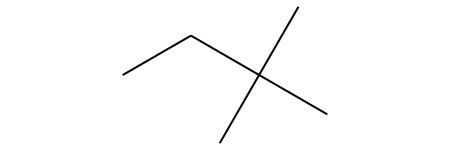

In [76]:
from rdkit.Chem.rdchem import RWMol
# https://github.com/wengong-jin/hgraph2graph/blob/master/hgraph/chemutils.py

def copy_atom(atom, atommap=True):
    new_atom = Chem.Atom(atom.GetSymbol())
    new_atom.SetFormalCharge(atom.GetFormalCharge())
    if atommap: 
        new_atom.SetAtomMapNum(atom.GetAtomMapNum())
    return new_atom

# Need to convert Mol object to RWMol object (for "editing" purposes) ...
def get_rwmol(mol):
    new_mol = Chem.RWMol(Chem.MolFromSmiles(''))
    for atom in mol.GetAtoms():
        new_atom = copy_atom(atom)
        new_mol.AddAtom(new_atom)

    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtom().GetIdx()
        a2 = bond.GetEndAtom().GetIdx()
        bt = bond.GetBondType()
        new_mol.AddBond(a1, a2, bt)
    return new_mol

rwmol = get_rwmol(mol)
display(rwmol)

### Decided to just use EvoMol's `MolGraph` object class ... 

# <font color=red> CURRENT BUG: Something to do with kekulization ... reproduce bug by using df.smiles[6] for the smiles ...

In [77]:
import molgraph
graph = molgraph.MolGraph(rwmol)
graph

CCC(C)(C)C

# <font color=blue> First goal: "Add atom"

In [79]:
# https://github.com/jules-leguy/EvoMol/blob/4ec88d635393889f847471f5b48d23eaa61fa70c/...
# ...evomol/molgraphops/actionspace.py#L383
    
graph = molgraph.MolGraph(rwmol)
display(graph)

# Adding the atom
graph.add_atom('N')
display(graph)

# Creating a bond from the last inserted atom to the existing one
graph.add_bond(graph.get_n_atoms() - 1, 1)
display(graph)

CCC(C)(C)C

CCC(C)(C)C.N

CC(N)C(C)(C)C

In [90]:
import random
import numpy as np

random.seed(666)

def randomly_add_atom(graph,atom_type='O'):
    
    idc = np.arange(graph.mol_graph.GetNumAtoms())
    random.shuffle(idc)
    for i in idc:
        try:
            graph.add_atom(atom_type)
        except Exception as e:
            continue
    else:
        return None
    
    return graph

graph = molgraph.MolGraph(rwmol)
randomly_add_atom(graph)

### Note about EvoMol actionspace ... action_id = index on atoms !!!!

7

In [91]:
graph

CCC(C)(C)C.O.O.O.O.O.O